# Fraud Detection

In [5]:
!pip cache purge --quiet

In [6]:
!pip install matplotlib==3.10.5 \
             scikit-learn==1.7.1 \
             seaborn==0.13.2 --quiet

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import requests
import sklearn.metrics as metrics
import zipfile

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

INFO:matplotlib.font_manager:generated new fontManager


In [8]:
# If you've forked this repo, change OWNER to your GitHub username.
# REPO and BRANCH will normally stay the same unless you renamed them.
OWNER = "singlestore-cookbook"
REPO = "singlestore-cookbook.github.io"
BRANCH = "refs/heads/main"

BASE_URL = f"https://raw.githubusercontent.com/{OWNER}/{REPO}/{BRANCH}/code/part-spark-and-kafka/apache-spark/datasets"

In [9]:
zip_url = f"{BASE_URL}/creditcard.csv.zip"

response = requests.get(zip_url)
response.raise_for_status()

with open("creditcard.csv.zip", "wb") as f:
    f.write(response.content)

with zipfile.ZipFile("creditcard.csv.zip", "r") as z:
    z.extract("creditcard.csv")

In [10]:
creditcard_csv_url = "creditcard.csv"

creditcard_df = pd.read_csv(creditcard_csv_url)

In [11]:
creditcard_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [12]:
# Count how many times each class appears
creditcard_df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

<div class="alert alert-block alert-warning">
    <b class="fa fa-solid fa-exclamation-circle"></b>
    <div>
        <p><b>Action Required</b></p>
        <p>Select the database from the drop-down menu at the top of this notebook. It updates the <b>connection_url</b> which is used by SQLAlchemy to make connections to the selected database.</p>
    </div>
</div>

In [13]:
from sqlalchemy import *

db_connection = create_engine(connection_url)

In [14]:
with db_connection.begin() as conn:
    conn.execute(text(f"DROP TABLE IF EXISTS creditcard;"))

In [16]:
creditcard_df.to_sql(
    "creditcard",
    con = db_connection,
    if_exists = "replace",
    index = False,
    chunksize = 1000
)

284807

In [17]:
# Only select numeric columns, excluding Time and Class
X_numeric = creditcard_df[
    [c for c in creditcard_df.select_dtypes(include = "number").columns if c not in ["Time", "Class"]]
]

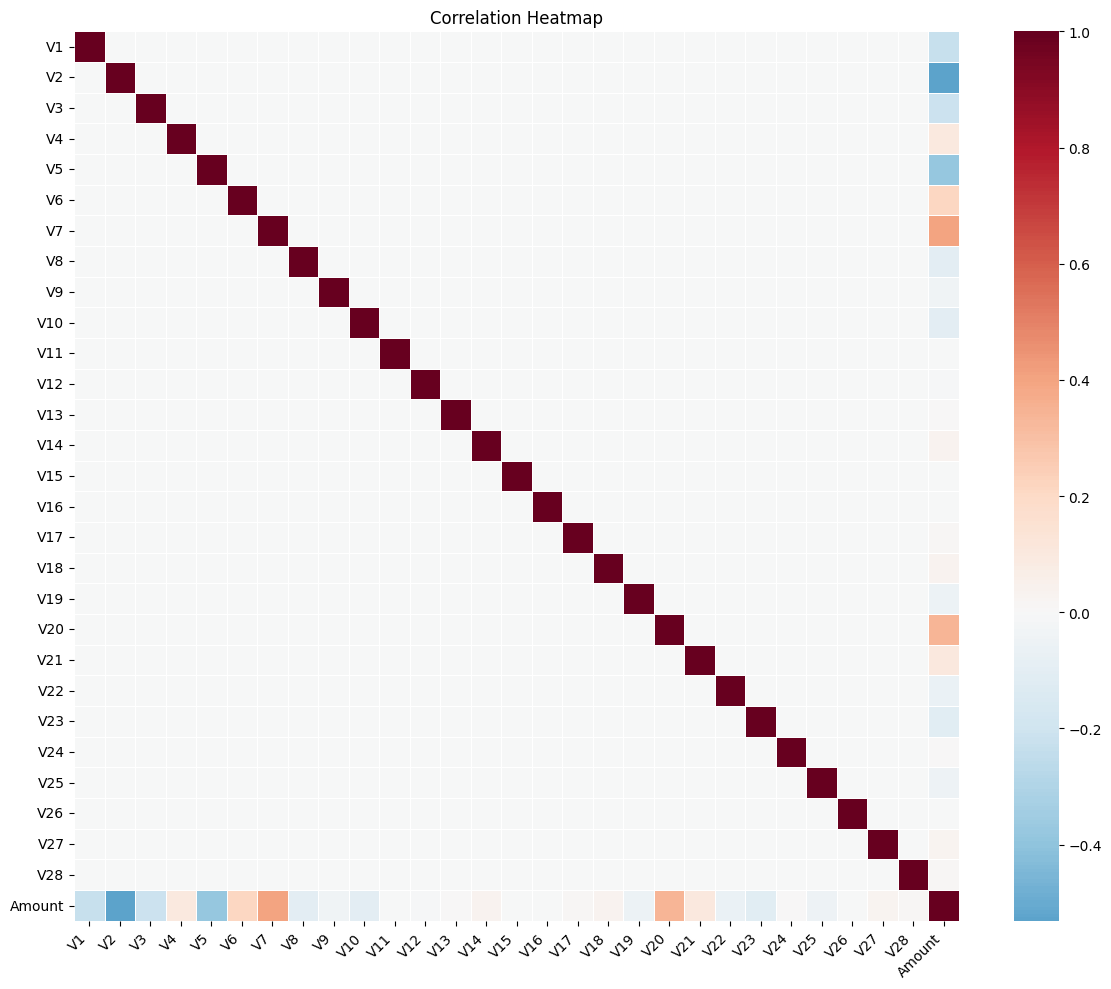

In [18]:
# Compute correlation matrix for numeric columns in fraud dataset
corr_matrix = X_numeric.corr()

# Set up the matplotlib figure
plt.figure(figsize = (12, 10))

# Create a heatmap with annotations and diverging colormap
sns.heatmap(
    corr_matrix,
    annot = False,
    fmt = ".2f",
    cmap = "RdBu_r",
    center = 0,
    square = False,
    cbar = True,
    linewidths = 0.5
)

# Rotate x-axis labels for readability
plt.xticks(rotation = 45, ha = "right")
plt.yticks(rotation = 0)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

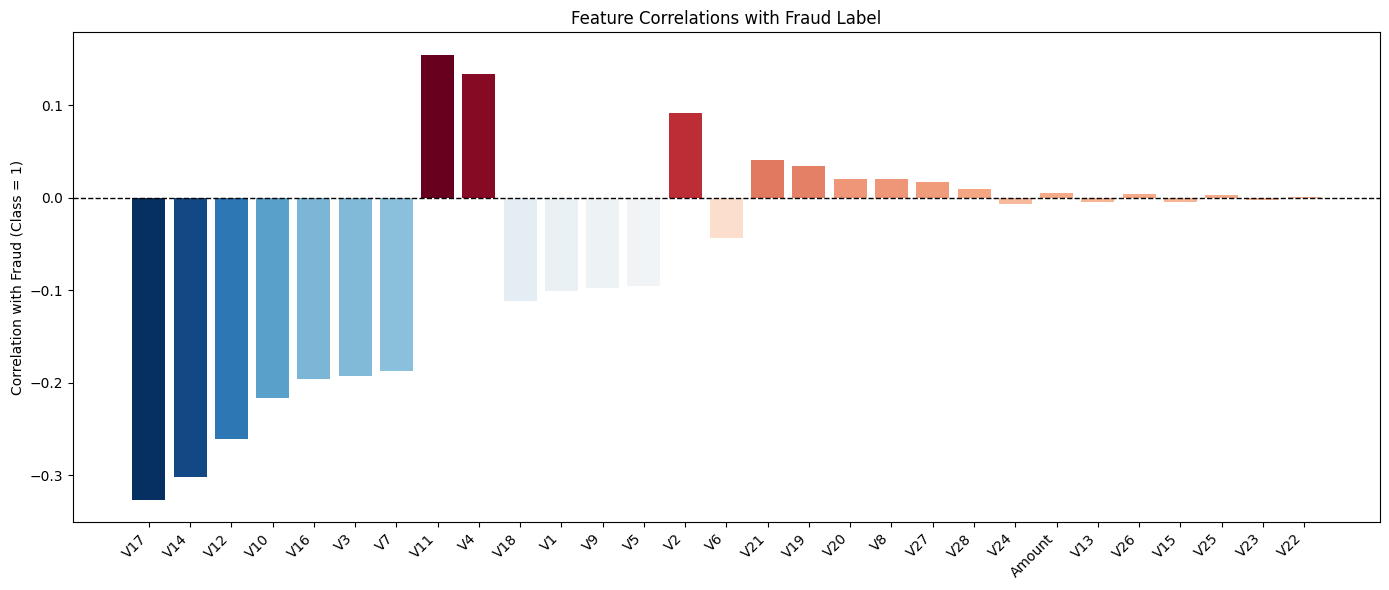

In [19]:
# Compute correlations of features with target Class
feature_corr = (X_numeric
    .join(creditcard_df["Class"])
    .corr()["Class"]
    .drop("Class")
    .sort_values(key = abs, ascending = False)
)

# Normalize correlation values for RdBu_r colors
cmap = sns.color_palette("RdBu_r", as_cmap = True)
normed = (feature_corr - feature_corr.min()) / (feature_corr.max() - feature_corr.min())
colors = [cmap(x) for x in normed]

# Plot vertical bar chart
plt.figure(figsize = (14, 6))
plt.bar(feature_corr.index, feature_corr.values, color = colors)
plt.axhline(0, color = "black", linewidth = 1, linestyle = "--")
plt.xticks(rotation = 45, ha = "right")

plt.ylabel("Correlation with Fraud (Class = 1)")
plt.title("Feature Correlations with Fraud Label")
plt.tight_layout()
plt.show()

In [20]:
SEED = 42

sampled_df = pd.concat([
    creditcard_df[creditcard_df["Class"] == 1],
    creditcard_df[creditcard_df["Class"] == 0].sample(frac = 0.01, random_state = SEED)
]).sort_values("Time").reset_index(drop = True)

In [21]:
# Count how many times each class appears
sampled_df["Class"].value_counts()

Class
0    2843
1     492
Name: count, dtype: int64

In [22]:
# "Class" is the label column
X = sampled_df.drop(columns = ["Time", "Class"])
y = sampled_df["Class"].astype(int)

In [23]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = SEED, stratify = y
)

In [24]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
# Train logistic regression with class balancing
model = LogisticRegression(
    max_iter = 1000,
    class_weight = "balanced",
    random_state = SEED
)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [26]:
# Probability-based predictions with threshold
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Set a custom threshold
threshold = 0.9
y_pred_threshold = (y_proba > threshold).astype(int)

In [27]:
# Sample weights for downsampling
# Non-fraud (0) -> weight = 100 (because only 1% kept)
# Fraud (1) -> weight = 1 (all kept)
sample_weights = y_test.apply(lambda x: 100 if x == 0 else 1)

In [28]:
accuracy = metrics.accuracy_score(y_test, y_pred_threshold, sample_weight = sample_weights)
precision = metrics.precision_score(y_test, y_pred_threshold, pos_label = 1, sample_weight = sample_weights)
recall = metrics.recall_score(y_test, y_pred_threshold, pos_label = 1, sample_weight = sample_weights)
f1 = metrics.f1_score(y_test, y_pred_threshold, pos_label = 1, sample_weight = sample_weights)

print(f"Weighted Accuracy: {accuracy:.4f}")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-score: {f1:.4f}")

Weighted Accuracy: 0.9974
Weighted Precision: 0.3808
Weighted Recall: 0.8311
Weighted F1-score: 0.5223


In [29]:
print("Classification Report (Unweighted):")
print(metrics.classification_report(
    y_test,
    y_pred_threshold,
    target_names = ["Genuine", "Fraud"])
)

print("Classification Report (Weighted):")
print(metrics.classification_report(
    y_test,
    y_pred_threshold,
    target_names = ["Genuine", "Fraud"],
    sample_weight = sample_weights)
)

Classification Report (Unweighted):
              precision    recall  f1-score   support

     Genuine       0.97      1.00      0.98       853
       Fraud       0.98      0.83      0.90       148

    accuracy                           0.97      1001
   macro avg       0.98      0.91      0.94      1001
weighted avg       0.97      0.97      0.97      1001

Classification Report (Weighted):
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00   85300.0
       Fraud       0.38      0.83      0.52     148.0

    accuracy                           1.00   85448.0
   macro avg       0.69      0.91      0.76   85448.0
weighted avg       1.00      1.00      1.00   85448.0



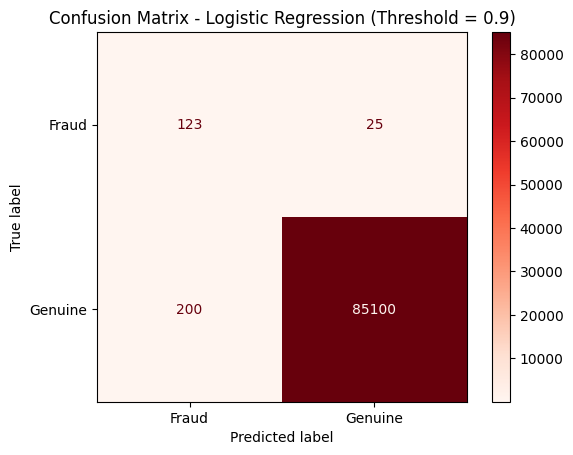

In [30]:
# Weighted confusion matrix
class_order = [1, 0]
cm = metrics.confusion_matrix(y_test, y_pred_threshold, labels = class_order, sample_weight = sample_weights)
display_labels = ["Fraud", "Genuine"]

disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = display_labels)
disp.plot(cmap = "Reds", values_format = ".0f")
plt.title(f"Confusion Matrix - Logistic Regression (Threshold = {threshold})")
plt.show()

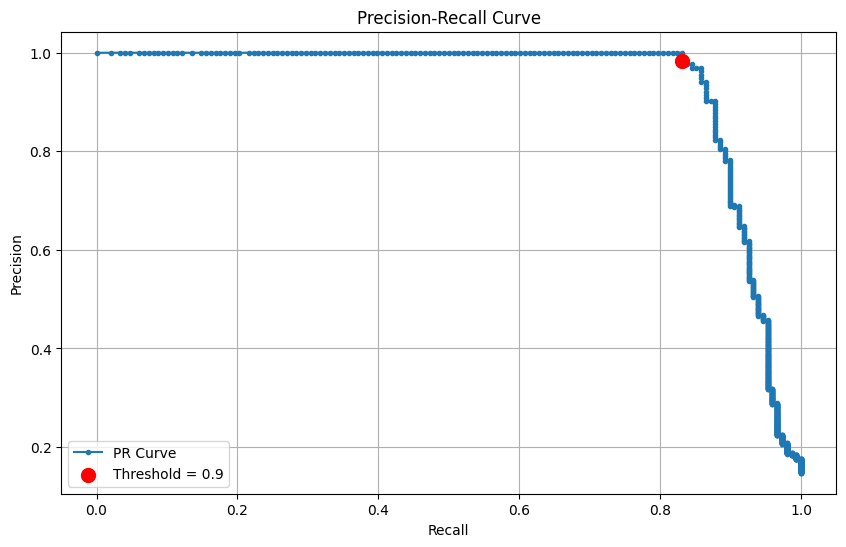

In [31]:
# Compute Precision-Recall curve
precision_vals, recall_vals, thresholds = metrics.precision_recall_curve(y_test, y_proba)

plt.figure(figsize = (10, 6))
plt.plot(recall_vals, precision_vals, marker = ".", label = "PR Curve")

# Mark the chosen threshold
# Find the closest threshold in the precision_recall_curve output
closest_idx = (np.abs(thresholds - threshold)).argmin()

plt.scatter(
    recall_vals[closest_idx],
    precision_vals[closest_idx],
    color = "red",
    s = 100,
    zorder = 5,
    label = f"Threshold = {threshold}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

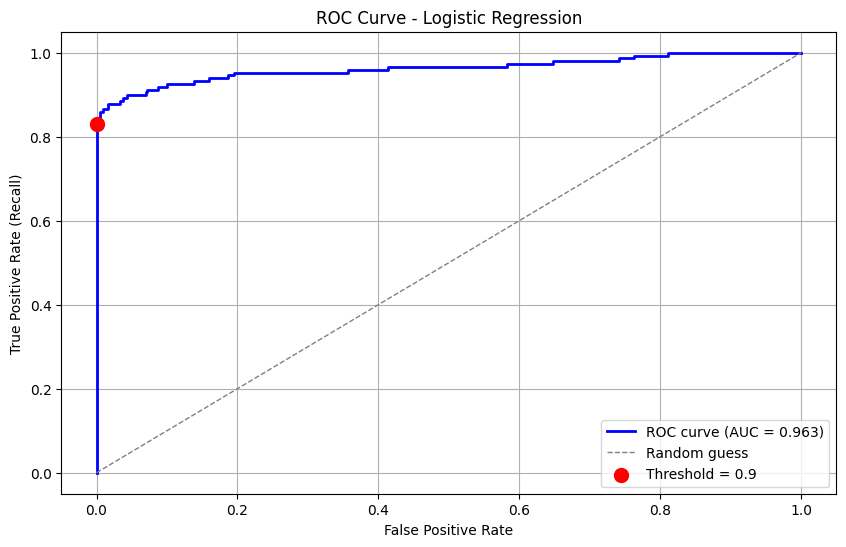

In [32]:
# Compute ROC curve
fpr, tpr, roc_thresholds = metrics.roc_curve(y_test, y_proba)

# Compute AUC
auc_score = metrics.roc_auc_score(y_test, y_proba)

# Find the closest threshold in roc_thresholds
closest_idx = (np.abs(roc_thresholds - threshold)).argmin()

plt.figure(figsize = (10, 6))
plt.plot(fpr, tpr, color = "blue", lw = 2, label = f"ROC curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], color = "gray", lw = 1, linestyle = "--", label = "Random guess")

# Mark the chosen threshold
plt.scatter(
    fpr[closest_idx],
    tpr[closest_idx],
    color = "red",
    s = 100,
    zorder = 5,
    label = f"Threshold = {threshold}"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [33]:
tables = ["train_data", "test_data"]

with db_connection.begin() as conn:
    for table in tables:
        conn.execute(text(f"DROP TABLE IF EXISTS {table};"))

In [34]:
(X_train.join(y_train)).to_sql(
    "train_data",
    con = db_connection,
    if_exists = "replace",
    index = False,
    chunksize = 1000
)

2334

In [35]:
(X_test.join(y_test)).to_sql(
    "test_data",
    con = db_connection,
    if_exists = "replace",
    index = False,
    chunksize = 1000
)

1001